# Embedding Model Experiment

## Objective

Evaluate local open-source embedding models for the RAG platform using
the project's HR/employee corpus.

The experiment will compare candidate models on:
- semantic retrieval quality
- embedding dimensionality
- model size
- inference latency
- batch throughput
- local resource requirements

The objective is to select an embedding model based on the trade-off
between retrieval quality and operational characteristics.

This experiment is standalone and does not form part of the RAG
platform runtime.

The selected model will be integrated into the platform later in M4.6.

## Candidates

The initial candidate set is:

1. `sentence-transformers/all-MiniLM-L6-v2`
2. `BAAI/bge-small-en-v1.5`
3. `BAAI/bge-base-en-v1.5`
4. `nomic-ai/nomic-embed-text-v1.5`

These candidates provide a useful progression from a lightweight
baseline to larger semantic-search-oriented models.

The candidate set may be expanded if the initial results reveal a
meaningful gap or an important limitation.

In [ ]:
from sentence_transformers import SentenceTransformer 

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

texts = [
    "Employees are entitled to 20 days of annual leave.",
    "Employees may work remotely two days per week.",
    "Employees must complete security training."
]

embeddings = model.encode(texts)
print (embeddings.shape)

# OUtput is (3, 384)
# means 3 input texts produced 3 vectors and 384 dimensions




Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21610.39it/s]


(3, 384)


## 1. Load the M3 Chunking Pipeline

The embedding experiment uses the existing Chunking domain and chunking
implementation.

No duplicate chunking logic is introduced here.

The experiment consumes `DocumentChunk` objects produced by the
platform's existing `RecursiveChunker`.

For embedding purposes, `DocumentChunk.text` is the input to the
embedding model.

The remaining chunk fields are retained so that experimental retrieval
results can always be traced back to the original chunk.

In [ ]:
from pathlib import Path 
import sys 
import time 

import numpy as np 
from sentence_transformers import SentenceTransformer

PROJECT_ROOT = Path.cwd().resolve()

print (PROJECT_ROOT)

if PROJECT_ROOT.name != "python":
    PROJECT_ROOT = PROJECT_ROOT / "python"

sys.path.insert(0, str(PROJECT_ROOT / "src"))


print (PROJECT_ROOT)

/Users/kashyaprajpurohit/myGitHubRepos/kr-ai-workshop/rag-platform/docs/experiments
/Users/kashyaprajpurohit/myGitHubRepos/kr-ai-workshop/rag-platform/docs/experiments/python


In [6]:
from pathlib import Path 
import sys 
import time 

import numpy as np 
from sentence_transformers import SentenceTransformer

# Make the local rag_platform package importable from the notebook
PYTHON_SRC = Path("../../python/src").resolve()

if str(PYTHON_SRC) not in sys.path:
    sys.path.insert(0, str(PYTHON_SRC))

from rag_platform.chunking.recursive import RecursiveChunker
from rag_platform.connectors.filesystem import FilesystemConnector
from rag_platform.domain.models import DocumentSource, SourceType
from rag_platform.domain.types import SourceID, TenantID

# Now, Locate the HR Corpus
DATA_ROOT = Path("../../data/raw/ZCompanyLLC").resolve()
print (DATA_ROOT)
print (DATA_ROOT.exists())

/Users/kashyaprajpurohit/myGitHubRepos/kr-ai-workshop/rag-platform/data/raw/ZCompanyLLC
True


In [7]:
# Now create the soource 

source = DocumentSource(
    id=SourceID("zcompanyllc-hr"),
    tenant_id=TenantID("zcompanyllc"),
    source_type=SourceType.FILE,
    uri=str(DATA_ROOT)
)

source


DocumentSource(id='zcompanyllc-hr', tenant_id='zcompanyllc', source_type=<SourceType.FILE: 'file'>, uri='/Users/kashyaprajpurohit/myGitHubRepos/kr-ai-workshop/rag-platform/data/raw/ZCompanyLLC')

In [8]:
# Read the corpus
connector = FilesystemConnector(source)
documents = connector.read()
print(f"Documents discovered:{len(documents)}")

for document in documents[:10]:
    print (document.id, 
           document.format, 
           document.metadata.get("Path"))

Documents discovered:85
3ee428108047ec7214bf9f7f0d3b572da20b6493f2480a568fc4c784695e3a07 markdown None
5b24aa48b248f06d9ee74872acc20c75bfa81dd5ca40ce69dcff2bef4a16b924 pdf None
9162524964b2751ffdb971a338497e24e83a6f6639770c6cee9c19ab8b261642 pdf None
c728632971e720b7da4efed9d1b9be81b082825f275dd2bb9b438b4ae9244efc pdf None
4c2c1f203229f7ab8e52e6c03c46b514988ad1f92f97600d6b3396f6f8c9d8a0 pdf None
0bb0df4b4a0537cb6f00ea56d70e7b9643ef45b35809c589e0a695922f4d39ac markdown None
1f4d88a4505861425bfbbb56055e7435f91e7562bd1efe529d7be25af61a32ac markdown None
d649aaa4035f63d46b68cf22c79bfebd264c827fd004d06e82e3feb6bc56a571 markdown None
ca0af879928dea5fc38fbb88b5ab9d3abc066698fcd2d9eaf3a90ff4334bdf72 markdown None
5b589702e0389af29597689e4e39e2e7023d6fa3c6f50f306896786885a532e0 markdown None


In [9]:
# Parse the documents 
from rag_platform.parsers.markdown import MarkdownParser
from rag_platform.parsers.pdf import PDFParser
from rag_platform.parsers.text import TextParser

parsers = {
    "markdown": MarkdownParser(),
    "pdf": PDFParser(),
    "txt": TextParser(),
}

parsed_documents = []

for document in documents:
    parser = parsers[document.format.value]
    parsed_documents.append(parser.parse(document))

print(f"Parsed documents: {len(parsed_documents)}")

Parsed documents: 85


### Product Chunks 

In [10]:
chunker = RecursiveChunker(
    chunk_size=1000,
    chunk_overlap=150,
)

chunks = []

for document in parsed_documents:
    chunks.extend(chunker.chunk(document))

print(f"Total chunks: {len(chunks)}")

for chunk in chunks[:5]:
    print("=" * 80)
    print("chunk_id:", chunk.chunk_id)
    print("document_id:", chunk.document_id)
    print("sequence:", chunk.sequence_number)
    print("length:", len(chunk.text))
    print(chunk.text[:300])

Total chunks: 88
chunk_id: 589bf6debddc6db2e50c81b7363c808c31d2e3fc8534a113ae8fd289e3c87286
document_id: 3ee428108047ec7214bf9f7f0d3b572da20b6493f2480a568fc4c784695e3a07
sequence: 0
length: 1000
# Fictional Global HR RAG Demo Corpus

This corpus is intentionally fictional and exists only for demonstrating a production-oriented RAG pipeline.

## Jurisdiction rules

1. Every employee has a **base location**.
2. For employees whose base location is Germany or India, the policy of the **host co
chunk_id: 738ce37a15703ed1580bc7f7ae5e219ad576a7113347404e7a5f372c3f8acbd7
document_id: 3ee428108047ec7214bf9f7f0d3b572da20b6493f2480a568fc4c784695e3a07
sequence: 1
length: 586
proval requirements for extended leave; they do not automatically cancel statutory leave.
7. Holiday calendars are country-specific and should be interpreted using the employee's applicable jurisdiction under the rules above.

## Dataset composition

- Sweden: 10 employees
- Germany: 5 employees
- I
chunk_id: b006998df0654332

### Define the models 



In [11]:
MODEL_NAMES = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "BAAI/bge-small-en-v1.5",
    "BAAI/bge-base-en-v1.5",
]

print(MODEL_NAMES)

chunk_texts = [chunk.text for chunk in chunks]

print(f"Chunks: {len(chunk_texts)}")
print(f"First chunk characters: {len(chunk_texts[0])}")

['sentence-transformers/all-MiniLM-L6-v2', 'BAAI/bge-small-en-v1.5', 'BAAI/bge-base-en-v1.5']
Chunks: 88
First chunk characters: 1000


In [12]:
# Model #1 

model = SentenceTransformer(MODEL_NAMES[0])
print("Model:", MODEL_NAMES[0])


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9501.06it/s]


Model: sentence-transformers/all-MiniLM-L6-v2


In [13]:
start = time.perf_counter()

embeddings = model.encode(
    chunk_texts,
    convert_to_numpy=True,
    show_progress_bar=True,
)

elapsed = time.perf_counter() - start

print("Shape:", embeddings.shape)
print(f"Elapsed: {elapsed:.3f} seconds")
print(f"Chunks/sec: {len(chunk_texts) / elapsed:.2f}")

Batches: 100%|██████████| 3/3 [00:00<00:00, 12.36it/s]

Shape: (88, 384)
Elapsed: 0.246 seconds
Chunks/sec: 357.00


In [15]:
# Basic Vector Inspection

print("dtype:", embeddings.dtype)
print("shape:", embeddings.shape)
print("min:", embeddings.min())
print("max:", embeddings.max())
print("mean:", embeddings.mean())
print("std:", embeddings.std())

dtype: float32
shape: (88, 384)
min: -0.18868297
max: 0.20160101
mean: -0.00063775806
std: 0.05102705


In [16]:
print(embeddings[0][:10])

[ 0.0443863   0.05537255  0.05464614 -0.07429235  0.044803    0.0376136
 -0.01463789 -0.05169055 -0.02540768  0.00302529]


In [17]:
print("Contains NaN:", np.isnan(embeddings).any())
print("Contains Inf:", np.isinf(embeddings).any())

Contains NaN: False
Contains Inf: False


In [19]:
def benchmark_model(
    model_name: str,
    texts: list[str],
) -> dict:
    print(f"\nLoading: {model_name}")

    model = SentenceTransformer(model_name)

    dimension = model.get_sentence_embedding_dimension()

    start = time.perf_counter()

    embeddings = model.encode(
        texts,
        convert_to_numpy=True,
        show_progress_bar=True,
    )

    elapsed = time.perf_counter() - start

    return {
        "model": model_name,
        "dimensions": dimension,
        "shape": embeddings.shape,
        "elapsed_seconds": elapsed,
        "chunks_per_second": len(texts) / elapsed,
        "dtype": str(embeddings.dtype),
        "min": float(embeddings.min()),
        "max": float(embeddings.max()),
        "mean": float(embeddings.mean()),
        "std": float(embeddings.std()),
        "has_nan": bool(np.isnan(embeddings).any()),
        "has_inf": bool(np.isinf(embeddings).any()),
        "embeddings": embeddings,
    }

In [20]:
benchmark_results = []

for model_name in MODEL_NAMES:
    result = benchmark_model(
        model_name,
        chunk_texts,
    )
    benchmark_results.append(result)


Loading: sentence-transformers/all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18485.02it/s]
/var/folders/9c/f66h6y097gx3xsfk63y_wz0r0000gq/T/ipykernel_90915/1003142294.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()
Batches: 100%|██████████| 3/3 [00:00<00:00, 45.27it/s]



Loading: BAAI/bge-small-en-v1.5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21007.41it/s]
/var/folders/9c/f66h6y097gx3xsfk63y_wz0r0000gq/T/ipykernel_90915/1003142294.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()
Batches: 100%|██████████| 3/3 [00:00<00:00, 30.29it/s]



Loading: BAAI/bge-base-en-v1.5


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 26931.68it/s]
/var/folders/9c/f66h6y097gx3xsfk63y_wz0r0000gq/T/ipykernel_90915/1003142294.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()
Batches: 100%|██████████| 3/3 [00:00<00:00,  7.40it/s]


In [21]:
for result in benchmark_results:
    print("=" * 80)
    print("Model:", result["model"])
    print("Dimensions:", result["dimensions"])
    print("Shape:", result["shape"])
    print(f"Elapsed: {result['elapsed_seconds']:.3f}s")
    print(f"Chunks/sec: {result['chunks_per_second']:.2f}")
    print("dtype:", result["dtype"])
    print("NaN:", result["has_nan"])
    print("Inf:", result["has_inf"])

Model: sentence-transformers/all-MiniLM-L6-v2
Dimensions: 384
Shape: (88, 384)
Elapsed: 0.068s
Chunks/sec: 1293.88
dtype: float32
NaN: False
Inf: False
Model: BAAI/bge-small-en-v1.5
Dimensions: 384
Shape: (88, 384)
Elapsed: 0.101s
Chunks/sec: 870.94
dtype: float32
NaN: False
Inf: False
Model: BAAI/bge-base-en-v1.5
Dimensions: 768
Shape: (88, 768)
Elapsed: 0.408s
Chunks/sec: 215.88
dtype: float32
NaN: False
Inf: False


In [22]:
for result in benchmark_results:
    embeddings_for_model = result["embeddings"]

    norms = np.linalg.norm(
        embeddings_for_model,
        axis=1,
    )

    print("=" * 80)
    print(result["model"])
    print(f"Mean norm: {norms.mean():.6f}")
    print(f"Min norm:  {norms.min():.6f}")
    print(f"Max norm:  {norms.max():.6f}")

sentence-transformers/all-MiniLM-L6-v2
Mean norm: 1.000000
Min norm:  1.000000
Max norm:  1.000000
BAAI/bge-small-en-v1.5
Mean norm: 1.000000
Min norm:  1.000000
Max norm:  1.000000
BAAI/bge-base-en-v1.5
Mean norm: 1.000000
Min norm:  1.000000
Max norm:  1.000000


| Model                 | Dim |        Time |           Throughput |
| --------------------- | --: | ----------: | -------------------: |
| **MiniLM-L6-v2**      | 384 | **0.068 s** | **1,293.9 chunks/s** |
| **BGE-small-en-v1.5** | 384 |     0.101 s |   **870.9 chunks/s** |
| **BGE-base-en-v1.5**  | 768 |     0.408 s |   **215.9 chunks/s** |

1. MiniLM is the clear efficiency winner.
On this workload it is roughly:
    1.5× faster than BGE-small
    6× faster than BGE-base

2. BGE-base has a significant dimensionality/storage cost.
    384 dimensions → 768 dimensions means approximately 2× the raw vector storage per chunk, before considering vector-store indexing overhead.

    For 88 chunks, that's irrelevant.
    For 10 million chunks, it becomes an architectural consideration.

3. The normalization result is particularly useful. All three models are producing unit-length vectors:
||embedding||₂ ≈ 1
That means for these generated vectors: cosine similarity and dot product are mathematically equivalent.

Because: cos(x,y)= x.y / (||x|| ||y||), and both norms are 1: cos(x,y)=x⋅y

Now, let us check it out.. 

## Experimental Queries
These queries are used only to compare embedding-model behavior. 
The queries target different semantic patterns present in the HR corpus:
- policy questions
- employee-specific information
- leave-related questions
- work-from-home policies
- employment/contract information

In [ ]:
queries = [
    "What is the company's policy for working from home?",
    "How many days of annual leave does an employee receive?",
    "What happens when an employee is placed on a performance improvement plan?",
    "What are Hannah Weber's employment terms?",
    "What is the process for requesting leave?",
]

Each model gets embeddings for the five queries..

In [ ]:

query_embeddings = {}

for result in benchmark_results:
    model_name = result["model"]

    model = SentenceTransformer(model_name)

    query_embeddings[model_name] = model.encode(
        queries,
        convert_to_numpy=True,
        show_progress_bar=False,
    )

    print(
        model_name,
        query_embeddings[model_name].shape,
    )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12871.71it/s]


sentence-transformers/all-MiniLM-L6-v2 (5, 384)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10102.35it/s]


BAAI/bge-small-en-v1.5 (5, 384)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10877.40it/s]


BAAI/bge-base-en-v1.5 (5, 768)


Nopw, implement cosine similarity...

In [24]:
def cosine_similarity(query_vector: np.ndarray, 
                      document_vectors: np.ndarray,) -> np.ndarray:
    query_norm = np.linalg.norm(query_vector)
    document_norms = np.linalg.norm(document_vectors, axis=1,)
    return (document_vectors @ query_vector)/(document_norms * query_norm)


Retrieve Top-5 Chunks 

In [25]:
def retrieve_top_k(
    query_vector: np.ndarray,
    document_vectors: np.ndarray,
    chunks: list,
    k: int = 5,
):
    scores = cosine_similarity(
        query_vector,
        document_vectors,
    )

    top_indices = np.argsort(scores)[::-1][:k]

    return [
        {
            "rank": rank,
            "chunk": chunks[index],
            "score": float(scores[index]),
        }
        for rank, index in enumerate(top_indices, start=1)
    ]

In [26]:
model_name = MODEL_NAMES[0]

results = retrieve_top_k(
    query_embeddings[model_name][0],
    benchmark_results[0]["embeddings"],
    chunks,
    k=5,
)

print("Query:")
print(queries[0])
print()

for result in results:
    chunk = result["chunk"]

    print("=" * 80)
    print(f"Rank:  {result['rank']}")
    print(f"Score: {result['score']:.4f}")
    print(f"Chunk: {chunk.chunk_id}")
    print(f"Doc:   {chunk.document_id}")
    print()
    print(chunk.text[:500])

Query:
What is the company's policy for working from home?

Rank:  1
Score: 0.5254
Chunk: 249509402ad2ba740e346b1fa0974d8e7f76cb7391a2186741b3b6805b81477a
Doc:   c35ef33d207779ba8a8eafdbcb46bb925fb0c9edf33f2c0356cb33770ffd70f2

# Germany Work From Home Policy

Employees based in Germany may request up to 2 regular remote-working days per week.

Temporary work from another country:
- Must be recorded before travel.
- Requires manager approval.
- Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad.
- Sweden-based employees remain under Swedish HQ policy globally.

Remote work does not itself change an employee's permanent base location.

Rank:  2
Score: 0.5247
Chunk: 92b982d144b0837e053302fe5fdf540e354492d96bf7a446334cda17f1f8db3e
Doc:   f36f23fbaef4516a9df3c5b7169a1a9995654f9152d290b74983d822e0976bf4

# Sweden Work From Home Policy

Employees based in Sweden may request up to 2 regular remote-working days per week.

Now, Run BGE-small and BGE-base on the same query

In [27]:
def show_top_results(
    model_index: int,
    query_index: int,
    k: int = 5,
) -> None:
    result = benchmark_results[model_index]

    model_name = result["model"]

    retrieved = retrieve_top_k(
        query_embeddings[model_name][query_index],
        result["embeddings"],
        chunks,
        k=k,
        
    )

    print("=" * 100)
    print(model_name)
    print("Query:", queries[query_index])
    print()

    for item in retrieved:
        chunk = item["chunk"]

        print(
            f"Rank {item['rank']} | "
            f"Score {item['score']:.4f} | "
            f"Doc {chunk.document_id}"
        )
        print(chunk.text[:350].replace("\n", " "))
        print()

For BGE-Small

In [28]:
show_top_results(
    model_index=1,
    query_index=0,
    k=5,
)

BAAI/bge-small-en-v1.5
Query: What is the company's policy for working from home?

Rank 1 | Score 0.7563 | Doc c35ef33d207779ba8a8eafdbcb46bb925fb0c9edf33f2c0356cb33770ffd70f2
# Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-working days per week.  Temporary work from another country: - Must be recorded before travel. - Requires manager approval. - Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad. - S

Rank 2 | Score 0.7450 | Doc 58c81401f73328db561305ebac315f8922fb4e040f7b9556b6c99b872cc8d2bb
# India Work From Home Policy  Employees based in India may request up to 2 regular remote-working days per week.  Temporary work from another country: - Must be recorded before travel. - Requires manager approval. - Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad. - Swede

Rank 3 | Score 0.7308 | Doc

For BGE-base

In [29]:
show_top_results(
    model_index=2,
    query_index=0,
    k=5,
)

BAAI/bge-base-en-v1.5
Query: What is the company's policy for working from home?

Rank 1 | Score 0.7208 | Doc 58c81401f73328db561305ebac315f8922fb4e040f7b9556b6c99b872cc8d2bb
# India Work From Home Policy  Employees based in India may request up to 2 regular remote-working days per week.  Temporary work from another country: - Must be recorded before travel. - Requires manager approval. - Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad. - Swede

Rank 2 | Score 0.7118 | Doc f36f23fbaef4516a9df3c5b7169a1a9995654f9152d290b74983d822e0976bf4
# Sweden Work From Home Policy  Employees based in Sweden may request up to 2 regular remote-working days per week.  Temporary work from another country: - Must be recorded before travel. - Requires manager approval. - Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad. - Swe

Rank 3 | Score 0.7105 | Doc 

# Qery result Analysis 

For the generic query: "What is the company's policy for working from home?"
all three models correctly identified the WFH policy cluster.

| Rank | MiniLM            | BGE-small          | BGE-base               |
| ---- | ----------------- | ------------------ | ---------------------- |
| 1    | Germany WFH       | Germany WFH        | **India WFH**          |
| 2    | Sweden WFH        | **India WFH**      | Sweden WFH             |
| 3    | India WFH         | Sweden WFH         | Germany WFH            |
| 4    | India contract    | Germany Leave/Work | Global HR Jurisdiction |
| 5    | Sweden Leave/Work | Sweden Leave/Work  | India Leave/Work       |

There are a few important observations.

1. All three pass the basic semantic test
The top three results for every model are the three country-specific WFH policies.
That's strong evidence that the embedding representation is capturing the topic correctly.

2. BGE-base is already doing something interesting
It put: India WFH Policy — Rank #1, whereas MiniLM and BGE-small put Germany first.
But we cannot call that an improvement yet because the query didn't specify India.

**Note: This is an important RAG evaluation principle:**
**A ranking difference is not necessarily a quality difference unless we have a relevance criterion that tells us what the correct ranking should be.**

3. BGE-base retrieved the Global HR Jurisdiction policy
That's actually semantically defensible.
The query asks about company WFH policy, and the Global HR Jurisdiction document discusses which country's policy governs employees under certain circumstances.
But whether that document belongs in the final context depends on the question being asked.

### Now, lets use a better test...

#### Specificity test 
Query: “How many days can an employee based in India work remotely each week?”
The known relevant chunk is India WOrk from home policy 

In [30]:
queries.append( "How many days can an employee based in India work remotely each week?")

query_embeddings = {}

for result in benchmark_results:
    model_name = result["model"]

    model = SentenceTransformer(model_name)

    query_embeddings[model_name] = model.encode(
        queries,
        convert_to_numpy=True,
        show_progress_bar=False,
    )


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10279.02it/s]


Now, Run all the three models for this query..

In [31]:
query_index = len(queries) - 1

for model_index in range(len(MODEL_NAMES)):
    show_top_results(
        model_index=model_index,
        query_index=query_index,
        k=5,
    )

sentence-transformers/all-MiniLM-L6-v2
Query: How many days can an employee based in India work remotely each week?

Rank 1 | Score 0.7065 | Doc 58c81401f73328db561305ebac315f8922fb4e040f7b9556b6c99b872cc8d2bb
# India Work From Home Policy  Employees based in India may request up to 2 regular remote-working days per week.  Temporary work from another country: - Must be recorded before travel. - Requires manager approval. - Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad. - Swede

Rank 2 | Score 0.6015 | Doc f6361a45a327f92ac764c1f93cb43afe5dbeb5409895c34fed4c84fa03c7aef7
# India Leave and Work Policy  **Fictional policy for the RAG demo.**  ## Annual leave - Standard annual leave entitlement: **24 working days per calendar year**. - Carry-forward limit: **8 days**. - Leave of more than 10 consecutive working days requires manager and HR approval. - Existing business-critical blackout periods may require additi

Analysis of the result 

| Model     | Correct result |      Score | Rank-2 score |        Gap |
| --------- | -------------- | ---------: | -----------: | ---------: |
| MiniLM    | India WFH      | **0.7065** |       0.6015 | **0.1050** |
| BGE-small | India WFH      | **0.8432** |       0.7885 | **0.0547** |
| BGE-base  | India WFH      | **0.8509** |       0.7923 | **0.0586** |


We can also observe that, MinilM has the largest separation.. 
MiniLM:
India WFH          0.7065
India Leave/Work   0.6015
Germany WFH        0.5675
Sweden WFH         0.5639

GE-Small:
India WFH          0.8432
Germany WFH        0.7885
Sweden WFH         0.7808
India Leave/Work   0.7532

BGE-base:
India WFH          0.8509
Germany WFH        0.7923
Sweden WFH         0.7794
India Leave/Work   0.7277

**Important point: Higher Cosince scores do not mean better retrieval separation**

COnsider the below six queries.. They cover 

| Query                   | Retrieval concept                      |
| ----------------------- | -------------------------------------- |
| Generic WFH             | broad semantic topic                   |
| Annual leave            | policy retrieval                       |
| PIP                     | HR process/concept                     |
| Hannah employment terms | entity + document semantics            |
| Leave request           | procedure                              |
| India remote work       | entity/location + semantic specificity |

In [34]:
queries = [
    "What is the company's policy for working from home?",
    "How many days of annual leave does an employee receive?",
    "What happens when an employee is placed on a performance improvement plan?",
    "What are Hannah Weber's employment terms?",
    "What is the process for requesting leave?",
    "How many days can an employee based in India work remotely each week?",
]

NOw, run the six-query experiment.. 

In [35]:
query_embeddings = {}

for result in benchmark_results:
    model_name = result["model"]

    model = SentenceTransformer(model_name)

    query_embeddings[model_name] = model.encode(
        queries,
        convert_to_numpy=True,
        show_progress_bar=False,
    )

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19206.72it/s]


In [36]:
def top_result_summary(
    model_index: int,
    query_index: int,
) -> dict:
    result = benchmark_results[model_index]
    model_name = result["model"]

    retrieved = retrieve_top_k(
        query_embeddings[model_name][query_index],
        result["embeddings"],
        chunks,
        k=3,
    )

    return {
        "model": model_name,
        "query": queries[query_index],
        "top_1_score": retrieved[0]["score"],
        "top_1_chunk_id": str(
            retrieved[0]["chunk"].chunk_id
        ),
        "top_1_text": retrieved[0]["chunk"].text[:120],
        "top_2_score": retrieved[1]["score"],
        "top_3_score": retrieved[2]["score"],
    }

In [37]:
for query_index, query in enumerate(queries):
    print("\n" + "=" * 100)
    print(f"QUERY {query_index + 1}: {query}")

    for model_index in range(len(MODEL_NAMES)):
        summary = top_result_summary(
            model_index,
            query_index,
        )

        print(
            f"\n{summary['model']}"
        )
        print(
            f"Top-1 score: {summary['top_1_score']:.4f}"
        )
        print(
            f"Top-1: {summary['top_1_text'].replace(chr(10), ' ')}"
        )
        print(
            f"Top-2 score: {summary['top_2_score']:.4f}"
        )
        print(
            f"Top-3 score: {summary['top_3_score']:.4f}"
        )


QUERY 1: What is the company's policy for working from home?

sentence-transformers/all-MiniLM-L6-v2
Top-1 score: 0.5254
Top-1: # Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-working days per week.  T
Top-2 score: 0.5247
Top-3 score: 0.5191

BAAI/bge-small-en-v1.5
Top-1 score: 0.7563
Top-1: # Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-working days per week.  T
Top-2 score: 0.7450
Top-3 score: 0.7308

BAAI/bge-base-en-v1.5
Top-1 score: 0.7208
Top-1: # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working days per week.  Tempo
Top-2 score: 0.7118
Top-3 score: 0.7105

QUERY 2: How many days of annual leave does an employee receive?

sentence-transformers/all-MiniLM-L6-v2
Top-1 score: 0.5651
Top-1: Employment Agreement — Clara Becker Employee ID: DE005 Base location: Germany Department: Finance Role: Senior Financial
Top-2 score: 0.5444
Top-3 score: 

### Result Analysis

| Query             | MiniLM                 | BGE-small              | BGE-base             |
| ----------------- | ---------------------- | ---------------------- | -------------------- |
| Generic WFH       | 🟢 WFH policy          | 🟢 WFH policy          | 🟢 WFH policy        |
| Annual leave      | 🟡 Employment contract | 🟡 Employment contract | 🟢 Leave/Work policy |
| PIP               | 🟢 Correct policy      | 🟢 Correct policy      | 🟢 Correct policy    |
| Hannah terms      | 🟢 Contract            | 🟢 Employee profile    | 🟢 Employee profile  |
| Leave request     | 🔴 Leave record        | 🟢 Application Rules   | 🟢 Application Rules |
| India remote work | 🟢 Correct policy      | 🟢 Correct policy      | 🟢 Correct policy    |

The standout is Query 5
"What is the process for requesting leave?"

MiniLM returned: Leave Record — Astrid Nilsson
That's semantically related to leave, but it doesn't answer the procedural question.

Both BGE models returned: Leave Application Rules

That's a meaningful retrieval-quality improvement.
This is exactly the kind of failure we care about in RAG: topic relevance isn't enough; we need answer-bearing context.

Further, We can observe a clear pattern.. 
MiniLM 
Very fast: 1294 chunks/sec
But it appears proe to broad semantic associations, i.e. it fetched leave record when asked for a 'leave query'
The actual should have been, when asked for 'leave query' it should have fetched 'leave application rules'

BGE-small
Speed is 'Fast' at 870.9 chunks/sec
And it has much better retrieval behavior across our probes.

BGE-base
Slow speed at 215.9 chunks/sec
It is also strong, and actually beats BGE-small on a couple of cases, particularly the annual-leave query.
But we're paying more:
    ~4× the embedding latency of BGE-small
    768 dimensions instead of 384
    ~2× vector storage
    greater compute cost 

### The Conclusion 
**BAAI/bge-small-en-v1.5** would be our embeddig model of choice !!

Reason: We have seen that it offers the best quality / operational trade-off.

                         Retrieval quality
                              ↑
                              │
                    BGE-base  ●
                              │
                BGE-small ●   │
                              │
       MiniLM ●               │
                              │
                              └────────────→ Cost

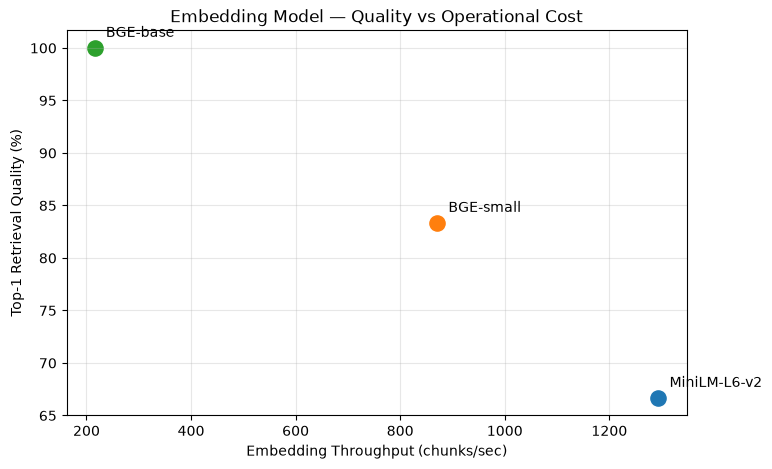

In [38]:
import matplotlib.pyplot as plt

# Manually scored from the six experimental queries.
# 1 = answer-bearing / appropriate Top-1 result
# 0 = weak or incorrect Top-1 result
retrieval_quality = {
    "MiniLM-L6-v2": 4,
    "BGE-small": 5,
    "BGE-base": 6,
}

throughput = {
    "MiniLM-L6-v2": 1293.88,
    "BGE-small": 870.94,
    "BGE-base": 215.88,
}

quality_pct = {
    model: score / 6 * 100
    for model, score in retrieval_quality.items()
}

fig, ax = plt.subplots(figsize=(8, 5))

for model in quality_pct:
    ax.scatter(
        throughput[model],
        quality_pct[model],
        s=120,
        label=model,
    )

    ax.annotate(
        model,
        (throughput[model], quality_pct[model]),
        xytext=(8, 8),
        textcoords="offset points",
    )

ax.set_xlabel("Embedding Throughput (chunks/sec)")
ax.set_ylabel("Top-1 Retrieval Quality (%)")
ax.set_title("Embedding Model — Quality vs Operational Cost")
ax.grid(True, alpha=0.3)

plt.show()